In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
from tqdm import tqdm
from src.data_loader import CWRUDataLoader
from src.feature_extractor import FeatureExtractor
from pathlib import Path

loader = CWRUDataLoader()
df     = loader.load_dataset('../data/raw/', verbose=False)
print(f"Total windows to process: {len(df)}")

extractor = FeatureExtractor()
records   = []
print("\nExtracting features...")

for idx, row in tqdm(df.iterrows(), total=len(df)):
    features = extractor.extract_all(row['signal'])
    features['label']      = row['label']
    features['fault_type'] = row['fault_type']
    features['severity']   = row['severity']
    features['load_hp']    = row['load_hp']
    records.append(features)

features_df = pd.DataFrame(records)
print(f"\nFeature dataset shape: {features_df.shape}")

Path('../data/processed').mkdir(exist_ok=True)
features_df.to_parquet('../data/processed/features_dataset.parquet', index=False)
print("Saved to data/processed/features_dataset.parquet")

Total windows to process: 2333

Extracting features...


100%|█████████████████████████████████████| 2333/2333 [00:03<00:00, 589.04it/s]



Feature dataset shape: (2333, 27)
Saved to data/processed/features_dataset.parquet


In [2]:
features_df = pd.read_parquet('../data/processed/features_dataset.parquet')
print("Dataset loaded successfully")
print(f"Shape: {features_df.shape}")
feature_cols = extractor.get_feature_names()
print(f"\nClass distribution:\n{features_df['fault_type'].value_counts()}")

Dataset loaded successfully
Shape: (2333, 27)

Class distribution:
fault_type
normal        824
inner_race    697
ball          464
outer_race    348
Name: count, dtype: int64


C:\Users\Avalokiteshwar Yadav\AppData\Local\Temp\ipykernel_7976\1928712432.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, patch_artist=True, labels=['Normal', 'Inner Race', 'Outer Race', 'Ball'], widths=0.5, medianprops=dict(color='black', linewidth=2))


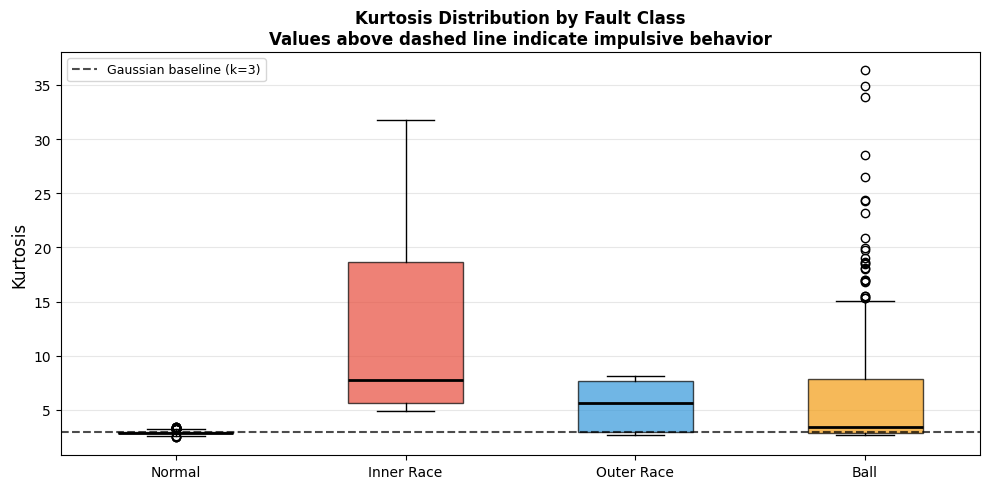

Median kurtosis per class:
  normal         : 2.906
  inner_race     : 7.789
  outer_race     : 5.587
  ball           : 3.418


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

COLORS = {'normal': '#2ecc71', 'inner_race': '#e74c3c', 'outer_race': '#3498db', 'ball': '#f39c12'}

fig, ax = plt.subplots(figsize=(10, 5))
data_by_class = [features_df[features_df['fault_type'] == ft]['kurtosis'].values for ft in COLORS.keys()]

bp = ax.boxplot(data_by_class, patch_artist=True, labels=['Normal', 'Inner Race', 'Outer Race', 'Ball'], widths=0.5, medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], COLORS.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=3.0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Gaussian baseline (k=3)')
ax.set_ylabel('Kurtosis', fontsize=12)
ax.set_title('Kurtosis Distribution by Fault Class\nValues above dashed line indicate impulsive behavior', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/day5_kurtosis_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Median kurtosis per class:")
for ft in COLORS.keys():
    print(f"  {ft:15s}: {features_df[features_df['fault_type'] == ft]['kurtosis'].median():.3f}")

C:\Users\Avalokiteshwar Yadav\AppData\Local\Temp\ipykernel_7976\275210341.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=features_df, x='fault_type', y=feature, ax=ax, palette=COLORS, order=COLORS.keys(), width=0.6)
C:\Users\Avalokiteshwar Yadav\AppData\Local\Temp\ipykernel_7976\275210341.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['N', 'IR', 'OR', 'B'], fontsize=8)
C:\Users\Avalokiteshwar Yadav\AppData\Local\Temp\ipykernel_7976\275210341.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=features_df, x='fault_type', y=feature, ax=ax, palette=COLORS, order=COLORS

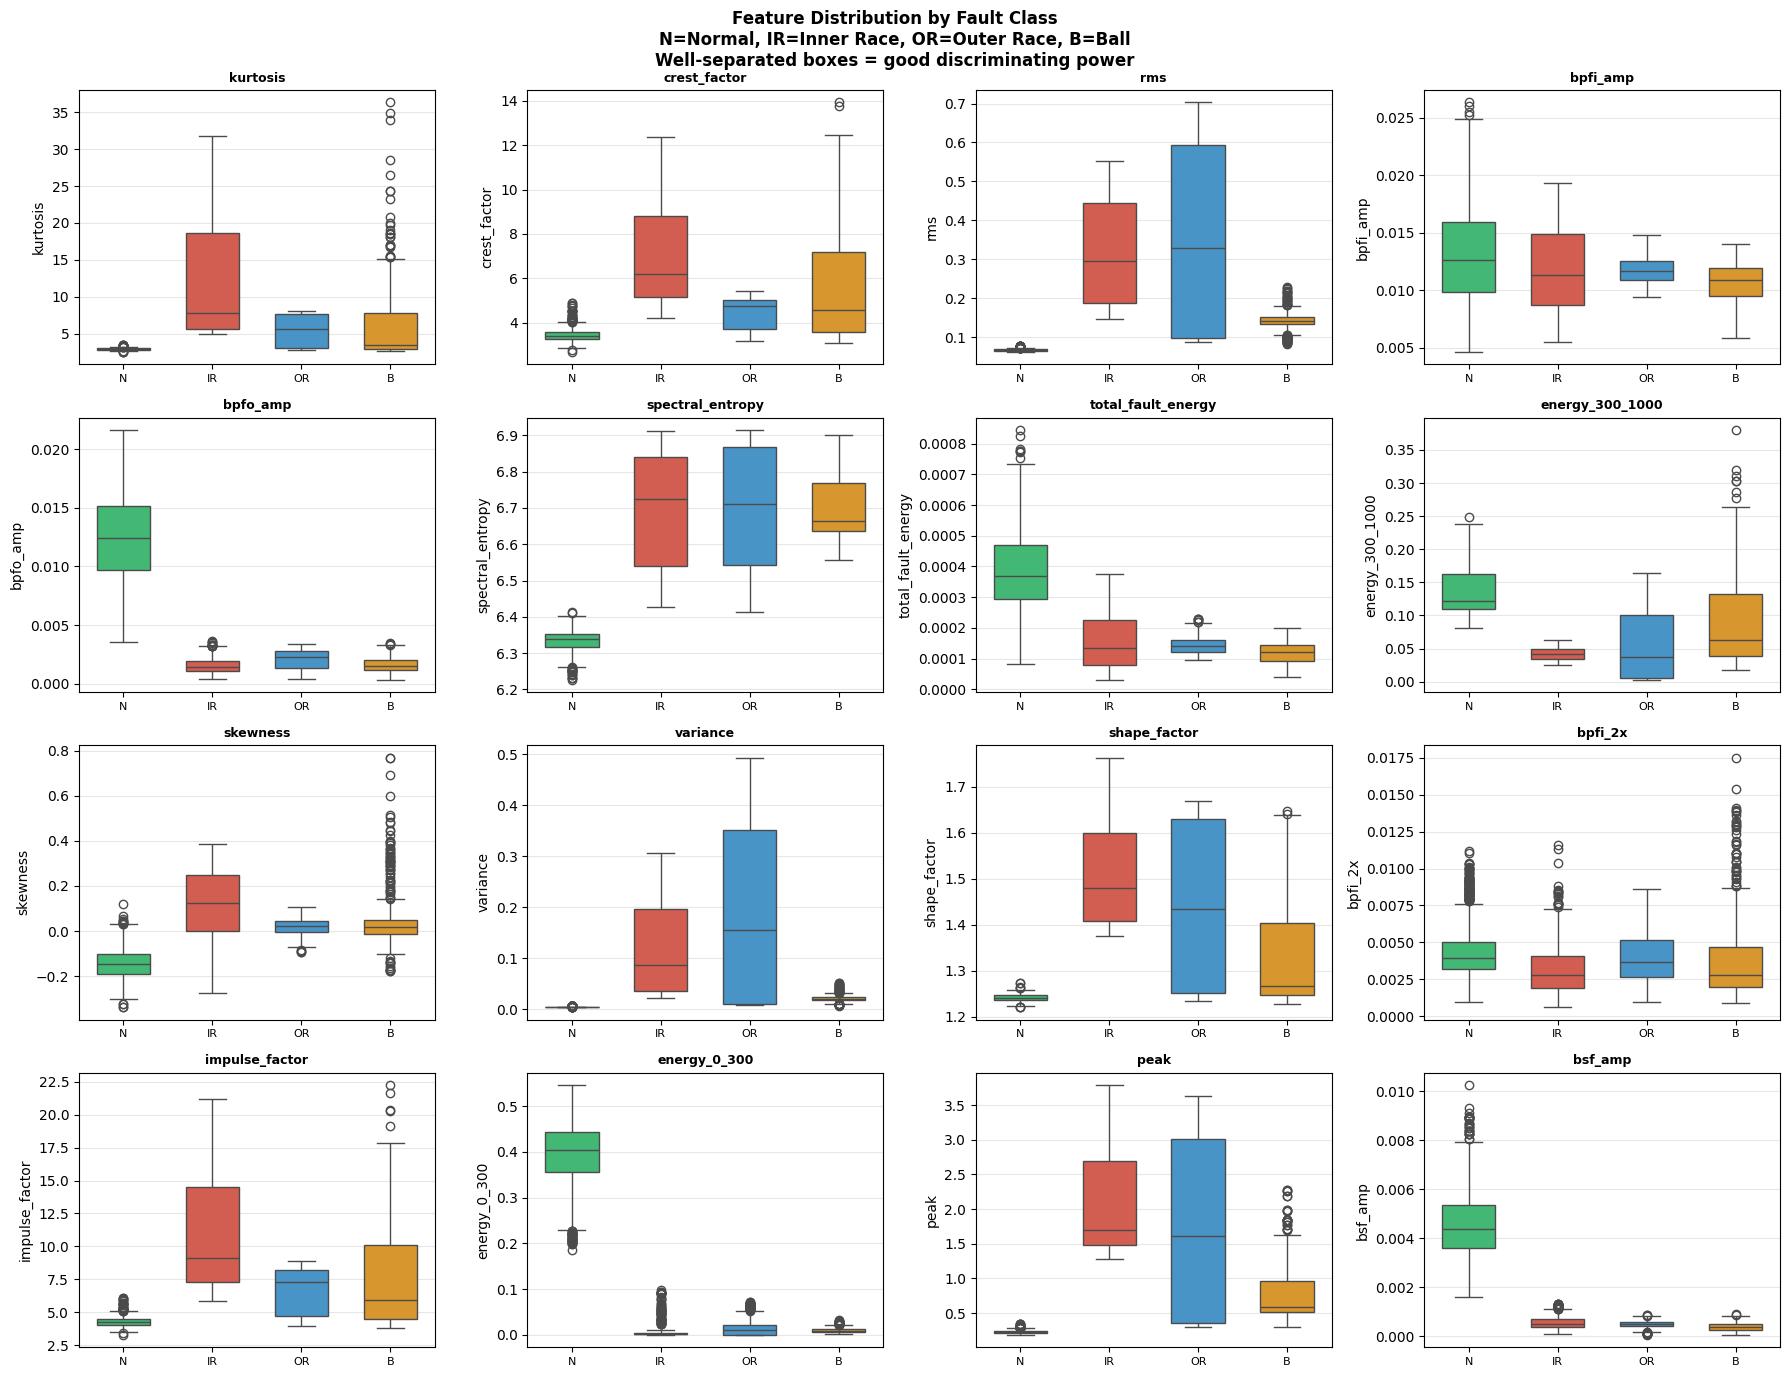

In [4]:
import seaborn as sns

top_features = ['kurtosis', 'crest_factor', 'rms', 'bpfi_amp', 'bpfo_amp', 'spectral_entropy', 'total_fault_energy', 'energy_300_1000', 'skewness', 'variance', 'shape_factor', 'bpfi_2x', 'impulse_factor', 'energy_0_300', 'peak', 'bsf_amp']

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, feature in zip(axes.flatten(), top_features):
    sns.boxplot(data=features_df, x='fault_type', y=feature, ax=ax, palette=COLORS, order=COLORS.keys(), width=0.6)
    ax.set_title(feature, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(['N', 'IR', 'OR', 'B'], fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Feature Distribution by Fault Class\nN=Normal, IR=Inner Race, OR=Outer Race, B=Ball\nWell-separated boxes = good discriminating power', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/day5_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

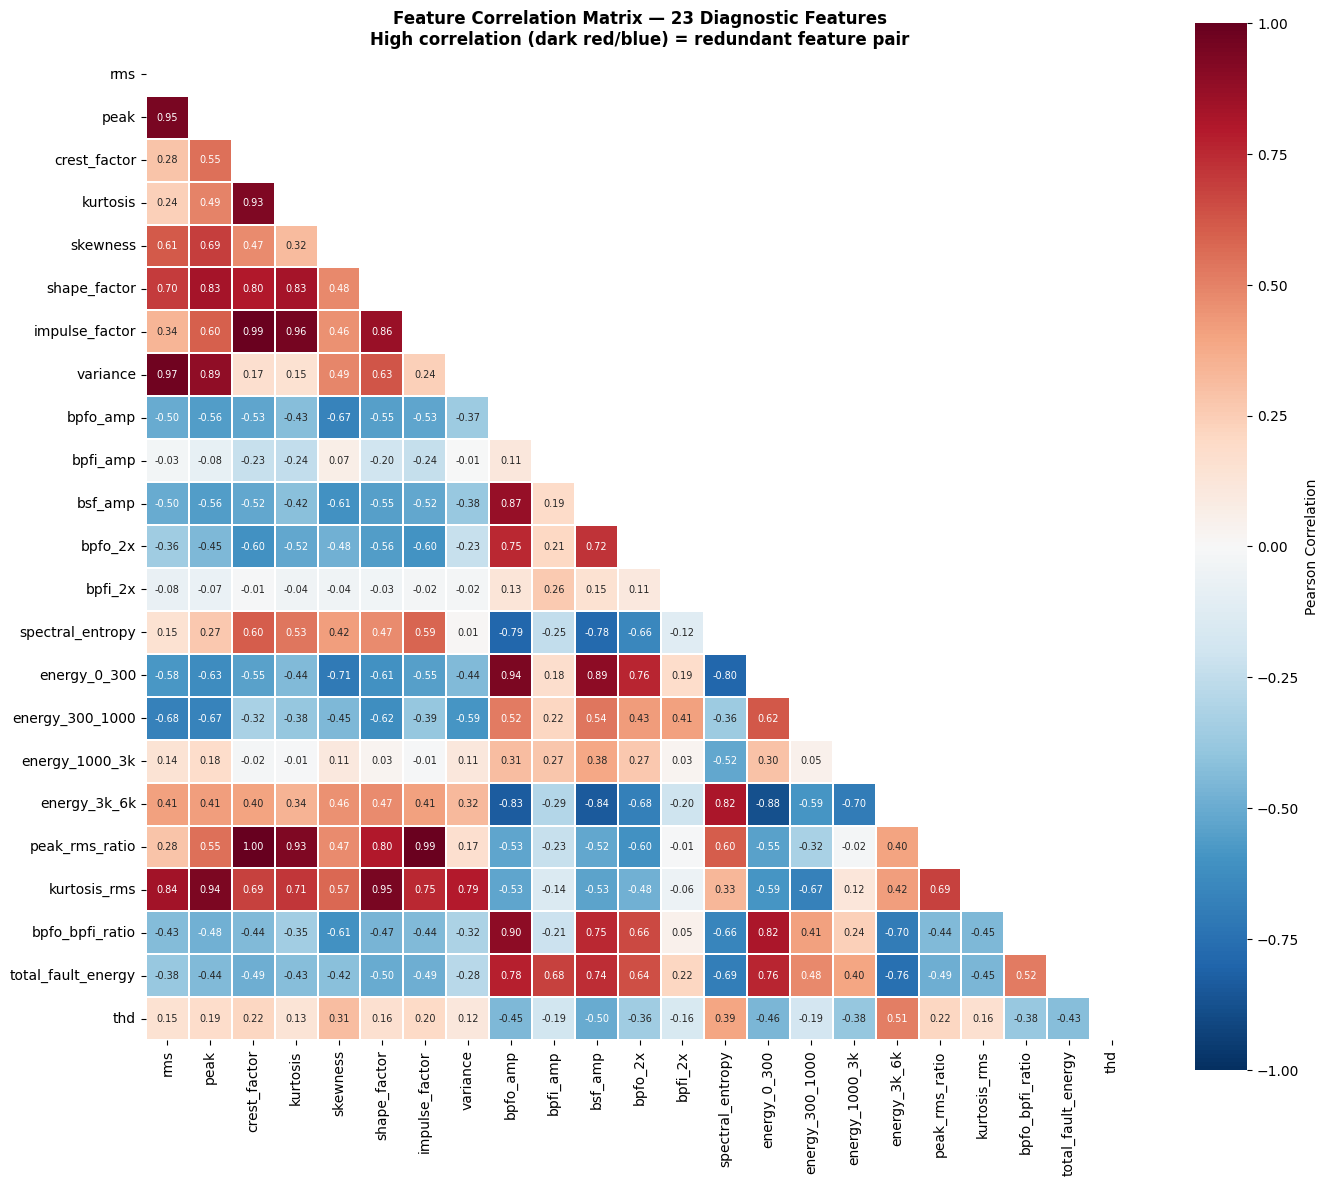


Highly correlated feature pairs (|r| > 0.85):
  rms                  ↔ peak                 : r = 0.946
  rms                  ↔ variance             : r = 0.973
  peak                 ↔ variance             : r = 0.889
  peak                 ↔ kurtosis_rms         : r = 0.943
  crest_factor         ↔ kurtosis             : r = 0.930
  crest_factor         ↔ impulse_factor       : r = 0.991
  crest_factor         ↔ peak_rms_ratio       : r = 1.000
  kurtosis             ↔ impulse_factor       : r = 0.961
  kurtosis             ↔ peak_rms_ratio       : r = 0.930
  shape_factor         ↔ impulse_factor       : r = 0.861
  shape_factor         ↔ kurtosis_rms         : r = 0.947
  impulse_factor       ↔ peak_rms_ratio       : r = 0.991
  bpfo_amp             ↔ bsf_amp              : r = 0.871
  bpfo_amp             ↔ energy_0_300         : r = 0.941
  bpfo_amp             ↔ bpfo_bpfi_ratio      : r = 0.897
  bsf_amp              ↔ energy_0_300         : r = 0.894
  energy_0_300         ↔ 

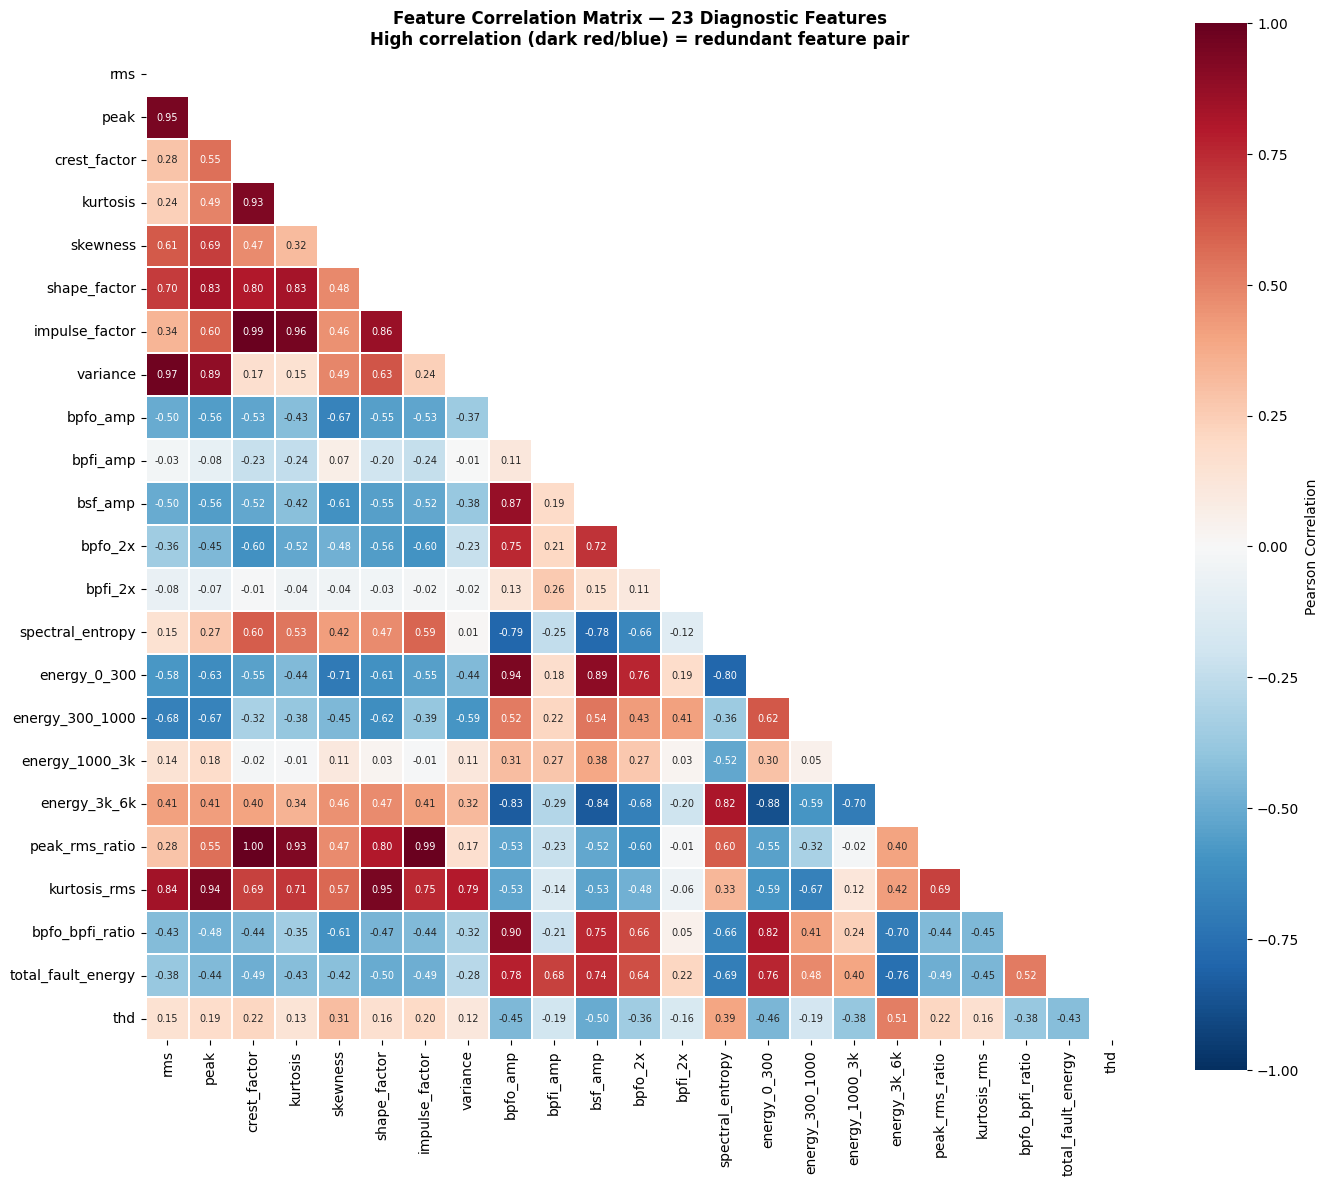


Highly correlated feature pairs (|r| > 0.85):
  rms                  ↔ peak                 : r = 0.946
  rms                  ↔ variance             : r = 0.973
  peak                 ↔ variance             : r = 0.889
  peak                 ↔ kurtosis_rms         : r = 0.943
  crest_factor         ↔ kurtosis             : r = 0.930
  crest_factor         ↔ impulse_factor       : r = 0.991
  crest_factor         ↔ peak_rms_ratio       : r = 1.000
  kurtosis             ↔ impulse_factor       : r = 0.961
  kurtosis             ↔ peak_rms_ratio       : r = 0.930
  shape_factor         ↔ impulse_factor       : r = 0.861
  shape_factor         ↔ kurtosis_rms         : r = 0.947
  impulse_factor       ↔ peak_rms_ratio       : r = 0.991
  bpfo_amp             ↔ bsf_amp              : r = 0.871
  bpfo_amp             ↔ energy_0_300         : r = 0.941
  bpfo_amp             ↔ bpfo_bpfi_ratio      : r = 0.897
  bsf_amp              ↔ energy_0_300         : r = 0.894
  energy_0_300         ↔ 

In [6]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fix path and load your Day 5 data
if '..' not in sys.path:
    sys.path.append('..')
from src.feature_extractor import FeatureExtractor

features_df = pd.read_parquet('../data/processed/features_dataset.parquet')
extractor    = FeatureExtractor()
feature_cols = extractor.get_feature_names()

# --- Now the rest of your cell will work perfectly ---
# Compute correlation matrix across all windows
corr_matrix = features_df[feature_cols].corr()
fig, ax = plt.subplots(figsize=(14, 12))

# Show only lower triangle (upper is mirror)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    annot_kws={'size': 7}, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, ax=ax, square=True,
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Pearson Correlation'}
)
ax.set_title(
    'Feature Correlation Matrix — 23 Diagnostic Features\n'
    'High correlation (dark red/blue) = redundant feature pair',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/figures/day6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print highly correlated pairs
print("\nHighly correlated feature pairs (|r| > 0.85):")
pairs_found = 0
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            print(f"  {feature_cols[i]:20s} ↔ {feature_cols[j]:20s} : r = {r:.3f}")
            pairs_found += 1
if pairs_found == 0:
    print("  No highly correlated pairs found — all features add information")# Compute correlation matrix across all windows
corr_matrix = features_df[feature_cols].corr()
fig, ax = plt.subplots(figsize=(14, 12))

# Show only lower triangle (upper is mirror)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    annot_kws={'size': 7}, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, ax=ax, square=True,
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Pearson Correlation'}
)
ax.set_title(
    'Feature Correlation Matrix — 23 Diagnostic Features\n'
    'High correlation (dark red/blue) = redundant feature pair',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/figures/day6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print highly correlated pairs
print("\nHighly correlated feature pairs (|r| > 0.85):")
pairs_found = 0
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            print(f"  {feature_cols[i]:20s} ↔ {feature_cols[j]:20s} : r = {r:.3f}")
            pairs_found += 1
if pairs_found == 0:
    print("  No highly correlated pairs found — all features add information")

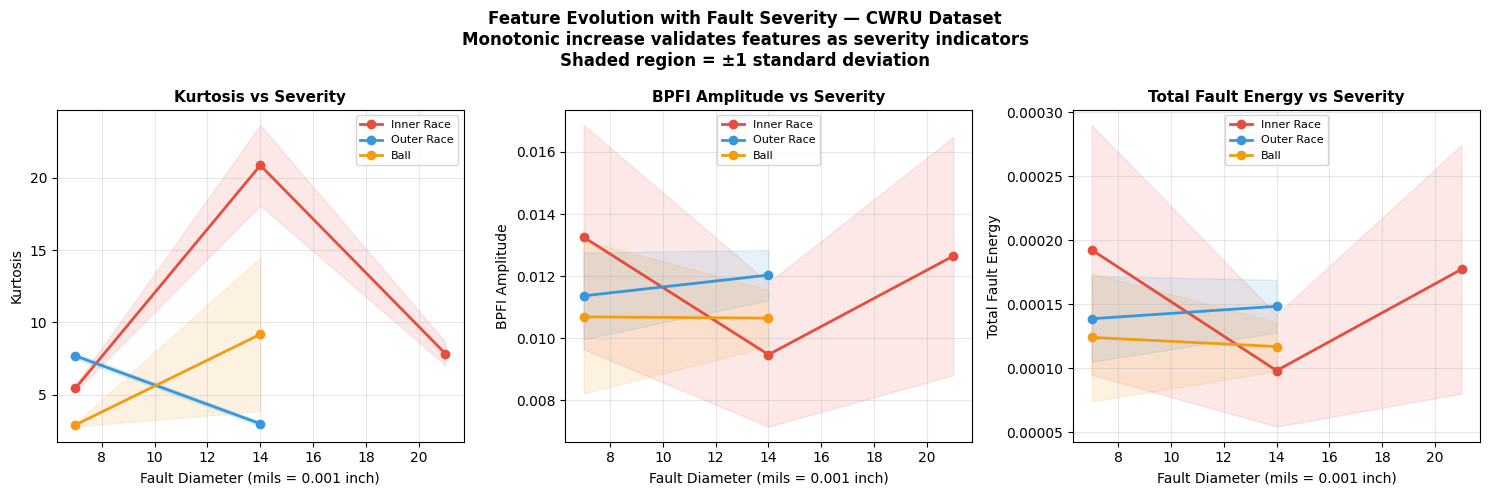

In [7]:
# How do features change as fault gets worse?
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
key_features = ['kurtosis', 'bpfi_amp', 'total_fault_energy']
labels_feats  = ['Kurtosis', 'BPFI Amplitude', 'Total Fault Energy']
fault_types  = ['inner_race', 'outer_race', 'ball']
fault_colors = ['#e74c3c', '#3498db', '#f39c12']

for ax, feat, flabel in zip(axes, key_features, labels_feats):
    for ft, fc in zip(fault_types, fault_colors):
        subset = features_df[(features_df['fault_type'] == ft) & (features_df['severity'] > 0)]
        if subset.empty:
            continue
        
        # Mean and std across windows for each severity level
        grouped = subset.groupby('severity')[feat]
        sev_mean = grouped.mean()
        sev_std  = grouped.std()
        
        ax.plot(
            sev_mean.index * 1000,   # convert inches to mils (×1000)
            sev_mean.values, marker='o', linewidth=2, color=fc, label=ft.replace('_', ' ').title()
        )
        ax.fill_between(
            sev_mean.index * 1000, sev_mean.values - sev_std.values, sev_mean.values + sev_std.values,
            alpha=0.12, color=fc
        )
        
    ax.set_xlabel('Fault Diameter (mils = 0.001 inch)', fontsize=10)
    ax.set_ylabel(flabel, fontsize=10)
    ax.set_title(f'{flabel} vs Severity', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'Feature Evolution with Fault Severity — CWRU Dataset\n'
    'Monotonic increase validates features as severity indicators\n'
    'Shaded region = ±1 standard deviation', fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/figures/day6_severity_progression.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
from scipy import stats as sp_stats

print("Statistical significance of class separation")
print("(Kruskal-Wallis test: p < 0.05 means classes are significantly different)")
print("=" * 60)

for feat in feature_cols:
    groups = [
        features_df[features_df['fault_type'] == ft][feat].values
        for ft in ['normal', 'inner_race', 'outer_race', 'ball']
    ]
    h_stat, p_val = sp_stats.kruskal(*groups)
    significance  = "✅ Significant" if p_val < 0.05 else "❌ Not significant"
    print(f"  {feat:22s}: p = {p_val:.2e}  {significance}")

Statistical significance of class separation
(Kruskal-Wallis test: p < 0.05 means classes are significantly different)
  rms                   : p = 0.00e+00  ✅ Significant
  peak                  : p = 0.00e+00  ✅ Significant
  crest_factor          : p = 2.36e-309  ✅ Significant
  kurtosis              : p = 2.30e-267  ✅ Significant
  skewness              : p = 1.86e-299  ✅ Significant
  shape_factor          : p = 0.00e+00  ✅ Significant
  impulse_factor        : p = 3.66e-306  ✅ Significant
  variance              : p = 0.00e+00  ✅ Significant
  bpfo_amp              : p = 0.00e+00  ✅ Significant
  bpfi_amp              : p = 2.85e-23  ✅ Significant
  bsf_amp               : p = 0.00e+00  ✅ Significant
  bpfo_2x               : p = 0.00e+00  ✅ Significant
  bpfi_2x               : p = 1.02e-51  ✅ Significant
  spectral_entropy      : p = 0.00e+00  ✅ Significant
  energy_0_300          : p = 0.00e+00  ✅ Significant
  energy_300_1000       : p = 7.68e-263  ✅ Significant
  energy_100

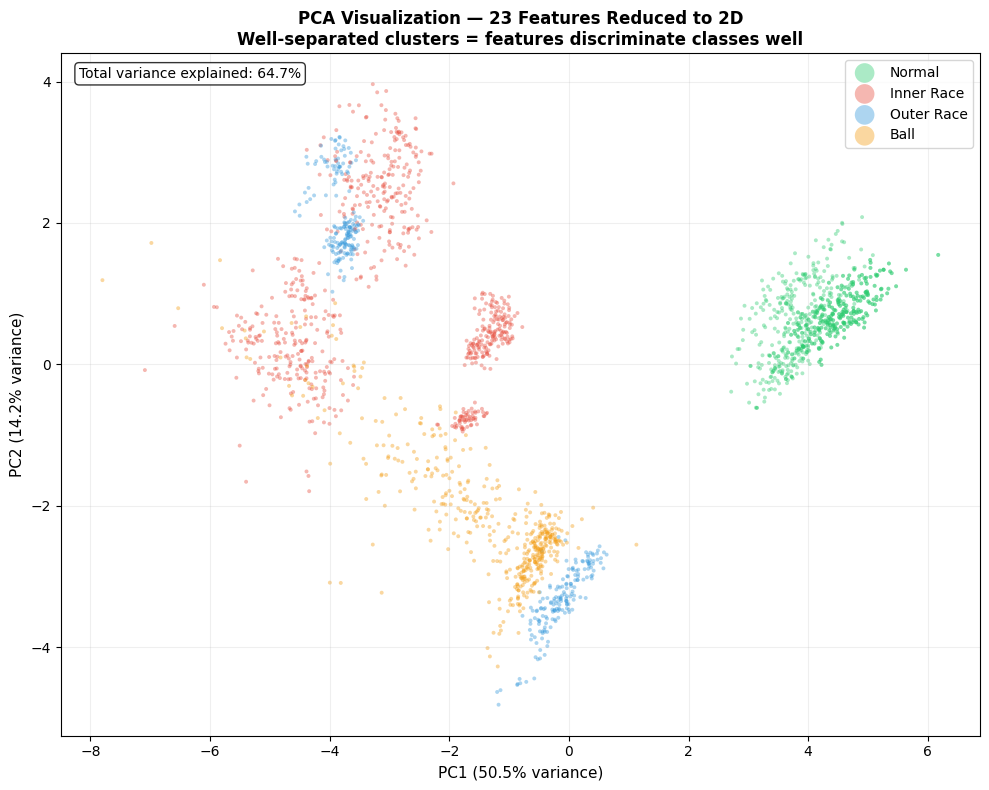

Variance explained by PC1: 50.5%
Variance explained by PC2: 14.2%
Total (2 components):      64.7%


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = features_df[feature_cols].values
y = features_df['label'].values

# Scale features — PCA is sensitive to scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce to 2D for visualization
pca   = PCA(n_components=2, random_state=42)
X_2d  = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
labels = ['Normal', 'Inner Race', 'Outer Race', 'Ball']

for class_idx, (color, label) in enumerate(zip(colors, labels)):
    mask = y == class_idx
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1], c=color, label=label,
        alpha=0.4, s=8, edgecolors='none'
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title(
    'PCA Visualization — 23 Features Reduced to 2D\n'
    'Well-separated clusters = features discriminate classes well',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10, markerscale=5)
ax.grid(True, alpha=0.2)

variance_explained = sum(pca.explained_variance_ratio_) * 100
ax.text(0.02, 0.98, f'Total variance explained: {variance_explained:.1f}%',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('../reports/figures/day6_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total (2 components):      {variance_explained:.1f}%")